## 📌 Objective


**`What characteristics are associated with successful movies, and how has the movie industry changed over time?`**

This analysis uses movie data from **TMDB (The Movie Database)** to identify trends, patterns, and characteristics associated with successful movies.

### 🔍 Key Questions

The analysis aims to answer the following questions:

1. **`Which movie genres perform best?`**
2. **`Are highly rated movies actually popular?`**
3. **`Does a larger audience lead to higher ratings?`**
4. **`Which years or release periods produced the strongest movies?`**
5. **`Has movie production increased over time?`**
6. **`Which genres dominate the movie industry?`**
7. **`Does movie popularity depend on ratings?`**
8. **`Are movies with a high number of votes more reliable than movies with very few votes?`**
9. **`Which movies show strong audience engagement?`**
10. **`Which movies should a streaming platform consider for acquisition or promotion?`**

---

## 📊 Analysis Areas

TMDB provides endpoints for **`popular movies`**, **`top-rated movies`**, and the powerful **`/discover/movie`** endpoint, which supports various filtering and sorting options.

Using TMDB movie data, this analysis will investigate:

- 📈 **`Movie industry trends over time`**
- 🎭 **`High-performing movie genres`**
- ⭐ **`Relationship between ratings and popularity`**
- 🗳️ **`Relationship between ratings and vote counts`**
- 📅 **`Most successful release periods`**
- 🏆 **`Characteristics of highly successful movies`**
- 👥 **`Movies with strong audience engagement`**
- 🎯 **`Potential movie recommendations for streaming platforms`**

---

## 🎯 Expected Outcome

The goal is to identify the **`key factors associated with movie success`** and understand how movie preferences, production, ratings, popularity, and audience engagement have evolved over time.

The findings can help a **`streaming platform or movie company`** make data-driven decisions about:

- Movie acquisition
- Content promotion
- Genre selection
- Audience targeting
- Identifying potentially successful movies

## IMPORTING LIBRARIES

In [1]:
import pandas as pd
import requests
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## LOADING DATA 
#### AS WE HAVE COLLECETD THE DATA FROM THE 'TMDB' API AND STORED IT INTO A CSV

In [2]:
df = pd.read_csv('popular_movies.csv')

## DATASET SHAPE

In [3]:
df.shape

(600, 16)

In [4]:
df.head(2)

,Unnamed: 0,adult,backdrop_path,genre_ids,id,title,original_language,original_title,overview,popularity,poster_path,release_date,softcore,video,vote_average,vote_count
0,0,False,/7iwUUcKURMT7aKfCwMy6YnGtchD.jpg,"[878, 28, 12]",969681,Spider-Man: Brand New Day,en,Spider-Man: Brand New Day,Fighting crime full-time as Spider-Man in a wo...,1346.7581,/bjiS5ipwxb9JFy3XRRN4OAilSeX.jpg,2026-07-29,False,False,7.893,2163
1,1,False,/RMXG8myu1aGlNUsRjtxzmpdMK0.jpg,"[12, 28, 14]",1368337,The Odyssey,en,The Odyssey,"Odysseus, the legendary King of Ithaca, embark...",620.9085,/5rhTDKUhPYvpdQIijFIs5VoWsON.jpg,2026-07-15,False,False,7.992,3198


In [5]:
df.tail(2)

,Unnamed: 0,adult,backdrop_path,genre_ids,id,title,original_language,original_title,overview,popularity,poster_path,release_date,softcore,video,vote_average,vote_count
598,598,False,/cF3H9pyUF6dsvqlYUcH0TyBAMTG.jpg,"[12, 16, 10751]",105864,The Good Dinosaur,en,The Good Dinosaur,An epic journey into the world of dinosaurs wh...,19.9641,/8RSkxOO80btfKjyiC5ZiTaCHIT8.jpg,2015-11-14,False,False,6.748,6123
599,599,False,/mIpCxBWNz6SHCQBe2K2PFr5MB7f.jpg,"[16, 10751, 35, 14]",62211,Monsters University,en,Monsters University,A look at the relationship between Mike and Su...,19.0584,/y7thwJ7z5Bplv6vwl6RI0yteaDD.jpg,2013-06-19,False,False,7.056,11500


## DELETING UNWANTED COLUMN

In [6]:
df = df.drop(columns='Unnamed: 0')

In [7]:
df.sample()

,adult,backdrop_path,genre_ids,id,title,original_language,original_title,overview,popularity,poster_path,release_date,softcore,video,vote_average,vote_count
60,False,/caBIySpwuFi2i7ynvHIlnxJLOdN.jpg,"[16, 28, 12]",1560520,Batman: Knightfall Part 1: Knightfall,en,Batman: Knightfall Part 1: Knightfall,"Arkham Asylum has been destroyed, and all its ...",66.0805,/360qdtu2hLnqMu8SVHMywn420w1.jpg,2026-06-23,False,False,8.4,18


## INFO ABOUT THE COLUMNS

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   adult              600 non-null    bool   
 1   backdrop_path      591 non-null    object 
 2   genre_ids          600 non-null    object 
 3   id                 600 non-null    int64  
 4   title              600 non-null    object 
 5   original_language  600 non-null    object 
 6   original_title     600 non-null    object 
 7   overview           596 non-null    object 
 8   popularity         600 non-null    float64
 9   poster_path        600 non-null    object 
 10  release_date       599 non-null    object 
 11  softcore           600 non-null    bool   
 12  video              600 non-null    bool   
 13  vote_average       600 non-null    float64
 14  vote_count         600 non-null    int64  
dtypes: bool(3), float64(2), int64(2), object(8)
memory usage: 58.1+ KB


## CHECKING FOR NULL VALUES

In [9]:
df.isnull().sum()

adult                0
backdrop_path        9
genre_ids            0
id                   0
title                0
original_language    0
original_title       0
overview             4
popularity           0
poster_path          0
release_date         1
softcore             0
video                0
vote_average         0
vote_count           0
dtype: int64

In [10]:
df.describe()

,id,popularity,vote_average,vote_count
count,6.000000e+02,600.000000,600.000000,600.000000
mean,5.945989e+05,41.101957,7.035495,8413.878333
std,5.677249e+05,70.828125,1.361715,8591.682780
min,1.100000e+01,14.194100,0.000000,0.000000
25%,1.373125e+04,21.091825,6.648500,653.000000
50%,4.219585e+05,25.943100,7.302000,6054.000000
75%,1.168522e+06,38.237850,7.821000,14151.750000
max,1.740877e+06,1346.758100,10.000000,40908.000000


### Until Now we have analysed :-
1. **`How many movies? = 600`**
2. **`Which columns have missing values? = 'backdrop_path', 'overview', 'release_date'`**
3. **`What are the data types? = object, int, bool, float`**
4. **`Are there suspicious values? = No`**
5. **`What is the range of ratings? = 0-10`**
6. **`What is the range of popularity? = 14 - 1346`**

## MODIFYING DATATYPES OF THE COLUMNS

### since release_date is in object format we have to change its Datatype

In [11]:
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")

In [12]:
df['release_date'].dtype

dtype('<M8[ns]')

### Now, since we have changed the type we can create usefull columns with the help of that

In [13]:
df["release_year"] = df["release_date"].dt.year
df["decade"] = (df["release_year"] // 10) * 10

## Checking For duplicates and Deleting them

In [14]:
df["id"].duplicated().sum()

np.int64(9)

In [15]:
df["title"].duplicated().sum()

np.int64(15)

In [16]:
df = df.drop_duplicates(subset="id")

In [17]:
df["title"].duplicated().sum()

np.int64(6)

In [18]:
df["id"].duplicated().sum()

np.int64(0)

In [19]:
df = df.drop_duplicates(subset="title")

In [20]:
df["title"].duplicated().sum()

np.int64(0)

In [21]:
df.shape

(585, 17)

### Note : In this process total 15 duplicate rows has been deleted from the df because duplicate entries can affect our analysis

In [22]:
df.head(2)

,adult,backdrop_path,genre_ids,id,title,original_language,original_title,overview,popularity,poster_path,release_date,softcore,video,vote_average,vote_count,release_year,decade
0,False,/7iwUUcKURMT7aKfCwMy6YnGtchD.jpg,"[878, 28, 12]",969681,Spider-Man: Brand New Day,en,Spider-Man: Brand New Day,Fighting crime full-time as Spider-Man in a wo...,1346.7581,/bjiS5ipwxb9JFy3XRRN4OAilSeX.jpg,2026-07-29,False,False,7.893,2163,2026.0,2020.0
1,False,/RMXG8myu1aGlNUsRjtxzmpdMK0.jpg,"[12, 28, 14]",1368337,The Odyssey,en,The Odyssey,"Odysseus, the legendary King of Ithaca, embark...",620.9085,/5rhTDKUhPYvpdQIijFIs5VoWsON.jpg,2026-07-15,False,False,7.992,3198,2026.0,2020.0


## Question 1 — Which Genres Perform Best?

### Next important column on which we have to shift our focus is 'genre_ids'

#### For this question , best way will be to create a new genre_df and explode all the genres associated with one movie. Because we can see that a movie can have multiple genres listed to it

In [65]:
df[['title','genre_ids']].head(30)

,title,genre_ids
0,Spider-Man: Brand New Day,"[878, 28, 12]"
1,The Odyssey,"[12, 28, 14]"
2,Mutiny,"[28, 53]"
3,Rage of Stars,"[28, 878, 53]"
4,Toy Story 5,"[16, 10751, 35, 12]"
5,Obsession,"[27, 53]"
6,Facing El Chapo,"[80, 28, 53]"
7,Moana,"[10751, 14, 35, 12]"
8,Spider-Man: No Way Home,"[28, 12, 878]"
9,Minions & Monsters,"[12, 16, 35, 10751, 14]"


In [24]:
genre_map = {28: "Action", 12: "Adventure", 16: "Animation", 35: "Comedy", 80: "Crime", 99: "Documentary", 18: "Drama",
    10751: "Family", 14: "Fantasy", 36: "History", 27: "Horror", 10402: "Music", 9648: "Mystery", 10749: "Romance", 878: "Science Fiction",
    10770: "TV Movie", 53: "Thriller", 10752: "War", 37: "Western" 
}
import ast

# we are converting list of genre_ids into the actucal list datatype, because if you see the dtype of genre_ids it is object and containing list
# in string format. But now we will convert it into normal list.
df["genre_ids"] = df["genre_ids"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

In [25]:
df["genre_ids"].iloc[0]

[878, 28, 12]

In [27]:
# Now we will map each genre_ids list to its name
df["genres"] = df["genre_ids"].apply(lambda genres: [genre_map.get(g, "Unknown") for g in genres])

In [28]:
df[["title", "genres"]].head()

,title,genres
0,Spider-Man: Brand New Day,"[Science Fiction, Action, Adventure]"
1,The Odyssey,"[Adventure, Action, Fantasy]"
2,Mutiny,"[Action, Thriller]"
3,Rage of Stars,"[Action, Science Fiction, Thriller]"
4,Toy Story 5,"[Animation, Family, Comedy, Adventure]"


In [29]:
df.columns

Index(['adult', 'backdrop_path', 'genre_ids', 'id', 'title',
       'original_language', 'original_title', 'overview', 'popularity',
       'poster_path', 'release_date', 'softcore', 'video', 'vote_average',
       'vote_count', 'release_year', 'decade', 'genres'],
      dtype='object')

In [30]:
df[['title','genres']].head(5)

,title,genres
0,Spider-Man: Brand New Day,"[Science Fiction, Action, Adventure]"
1,The Odyssey,"[Adventure, Action, Fantasy]"
2,Mutiny,"[Action, Thriller]"
3,Rage of Stars,"[Action, Science Fiction, Thriller]"
4,Toy Story 5,"[Animation, Family, Comedy, Adventure]"


In [31]:
genre_df = df.explode("genres")

In [32]:
genre_df.columns

Index(['adult', 'backdrop_path', 'genre_ids', 'id', 'title',
       'original_language', 'original_title', 'overview', 'popularity',
       'poster_path', 'release_date', 'softcore', 'video', 'vote_average',
       'vote_count', 'release_year', 'decade', 'genres'],
      dtype='object')

In [33]:
genre_df.shape

(1606, 18)

#### Original df has 585 rows , whereas now genre_Df has now 1606 rows . Which shows df has exploded itself and stored each genre of each movie in a separate row

In [34]:
genre_df[['title','genres']].head()

,title,genres
0,Spider-Man: Brand New Day,Science Fiction
0,Spider-Man: Brand New Day,Action
0,Spider-Man: Brand New Day,Adventure
1,The Odyssey,Adventure
1,The Odyssey,Action


In [35]:
genre_performance = genre_df.groupby("genres").agg(movie_count=("title", "count"), avg_rating=("vote_average", "mean"),
    avg_popularity=("popularity", "mean"), avg_vote_count=("vote_count", "mean")).sort_values(["movie_count","avg_popularity"], ascending=False)

genre_performance.reset_index()

,genres,movie_count,avg_rating,avg_popularity,avg_vote_count
0,Action,215,7.115065,49.706972,10131.906977
1,Adventure,198,7.227066,48.163447,12273.737374
2,Drama,168,7.122083,32.660074,8439.142857
3,Thriller,160,7.035388,41.876679,6329.868750
4,Comedy,138,7.023949,35.737017,7561.608696
5,Science Fiction,135,7.166119,54.489570,12006.896296
6,Fantasy,96,7.267635,42.676850,10542.739583
7,Family,89,7.383382,35.046282,9227.415730
8,Animation,85,7.454200,36.445965,9145.258824
9,Horror,84,6.616048,41.929575,3448.309524


In [36]:
genre_performance.describe()

,movie_count,avg_rating,avg_popularity,avg_vote_count
count,19.000000,19.000000,19.000000,19.000000
mean,84.473684,7.286891,39.365973,7728.617710
std,68.730851,0.381614,10.152733,3506.157233
min,2.000000,6.616048,23.967237,117.500000
25%,14.000000,7.075226,33.335896,6392.746875
50%,84.000000,7.267635,36.445965,8658.725000
75%,136.500000,7.438350,42.303213,9832.680761
max,215.000000,7.933500,67.354900,12273.737374


### This tells us :-
1. Total genres = 19
2. Avg movie per genre = 84.4
3. Min movie a genre have = 2
4. Max movie a genre have = 215

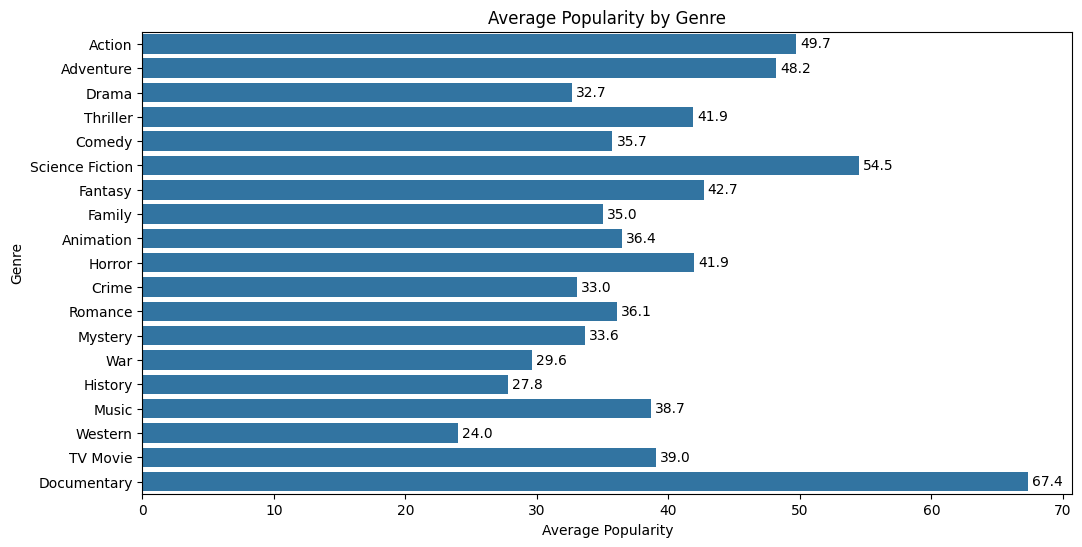

In [37]:
plt.figure(figsize=(12,6))

ax = sns.barplot(data=genre_performance.reset_index(),x="avg_popularity",y="genres")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

plt.title("Average Popularity by Genre")
plt.xlabel("Average Popularity")
plt.ylabel("Genre")
plt.show()

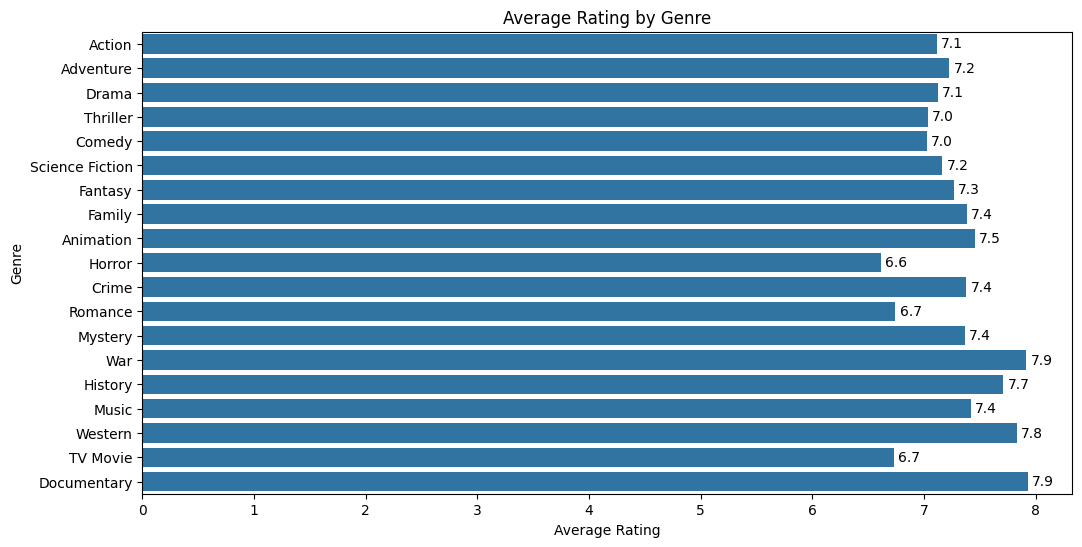

In [38]:
plt.figure(figsize=(12,6))

ax = sns.barplot(data=genre_performance.reset_index(),x="avg_rating",y="genres")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

plt.title("Average Rating by Genre")
plt.xlabel("Average Rating")
plt.ylabel("Genre")
plt.show()

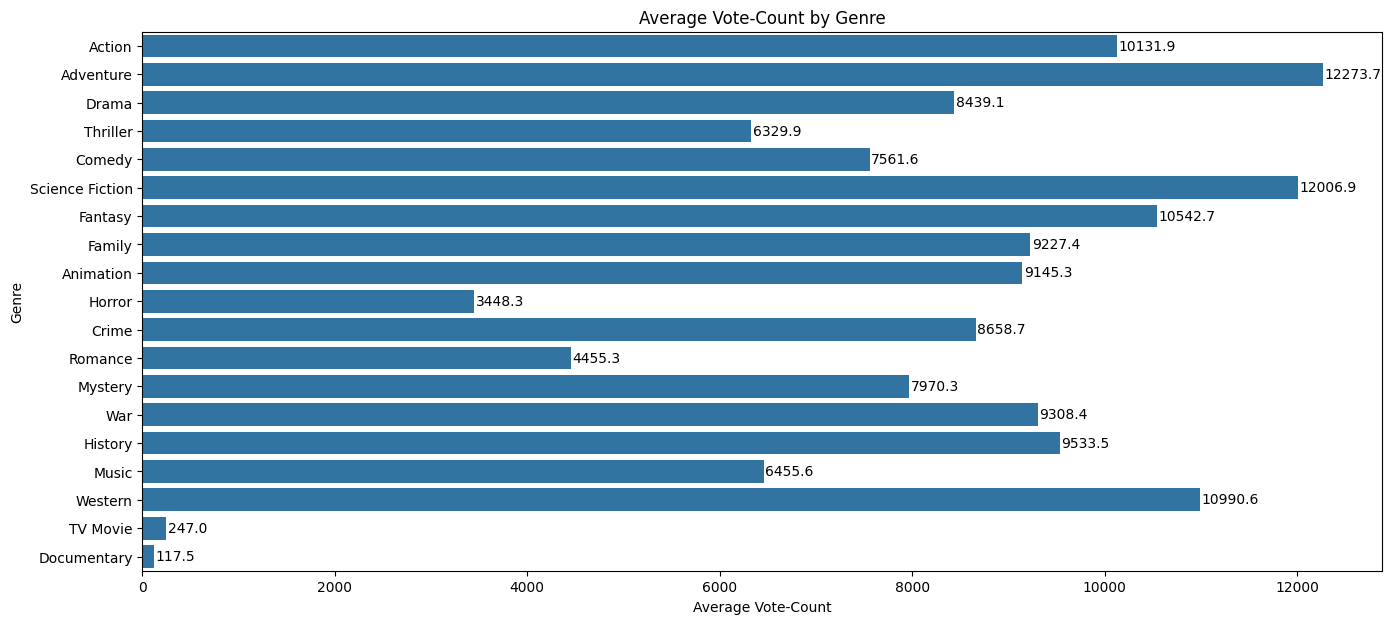

In [39]:
plt.figure(figsize=(16,7))

ax = sns.barplot(data=genre_performance.reset_index(),x="avg_vote_count",y="genres")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=1)

plt.title("Average Vote-Count by Genre")
plt.xlabel("Average Vote-Count")
plt.ylabel("Genre")
plt.show()

### Analysis that has been observed from these graphs are:- 

 - **`Science Fiction`** is one of the strongest overall genres, combining very high popularity (54.5) with strong ratings (7.2) and a very large audience.

 - **`Adventure`** also performs exceptionally well, with 48.2 popularity, 7.2 rating, and the highest average vote count (12,273.7).

 - **`Action`** is highly popular and widely watched, with 49.7 popularity and over 10,000 average votes, although its rating is slightly lower at 7.1.

 - **`Fantasy`** has a good balance of popularity (42.7), rating (7.3), and audience engagement (10,542.7 votes).

 - **`War and Documentary`** have the highest ratings (7.9), but they tell different stories. War films also have substantial audience engagement, whereas documentaries have only 117.5 average votes, so their 7.9 rating is based on a much smaller audience.

 - **`Horror and Romance`** perform relatively poorly: both have lower popularity and ratings, with Horror having the lowest rating (6.6) among the genres shown.

### CONCLUSION :- So from this we can conclude that Science Fiction, Adventure and Action are the top performing genres when considering popularity and audience engagement together.

## Question 2 — Are Highly Rated Movies Actually Popular?

In [40]:
df.columns

Index(['adult', 'backdrop_path', 'genre_ids', 'id', 'title',
       'original_language', 'original_title', 'overview', 'popularity',
       'poster_path', 'release_date', 'softcore', 'video', 'vote_average',
       'vote_count', 'release_year', 'decade', 'genres'],
      dtype='object')

In [41]:
df[["vote_average", "popularity"]].corr()

,vote_average,popularity
vote_average,1.000000,0.034653
popularity,0.034653,1.000000


In [42]:
correlation = df["vote_average"].corr(df["popularity"])

print("Correlation:", correlation)

Correlation: 0.03465252027269228


#### Note :- Since Correlation is around ~ 0.04 . So we can say that there is almost no correlation between Rating of a movie and popularity

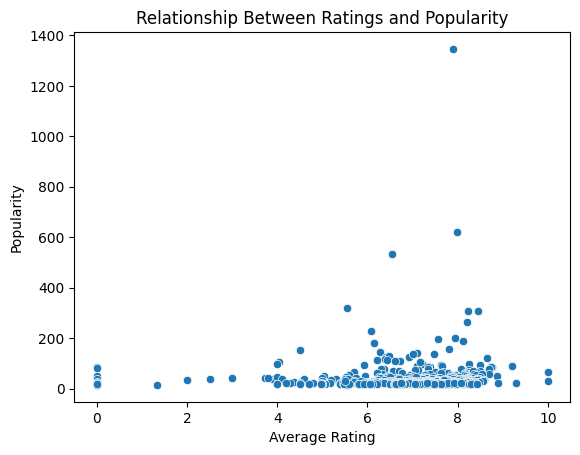

In [43]:
sns.scatterplot(data=df, x="vote_average", y="popularity" )

plt.title("Relationship Between Ratings and Popularity")
plt.xlabel("Average Rating")
plt.ylabel("Popularity")
plt.show()

#### CONCLUSION :- The correlation between movie ratings and popularity is only 0.0346, indicating a negligible relationship between the two variables. The scatter plot also shows no clear trend, with highly rated movies ranging from low to high popularity. Therefore, highly rated movies are not necessarily popular, suggesting that factors other than ratings play a more significant role in determining movie popularity.

## Question 3 — Does a Bigger Audience Lead to Higher Ratings?

In [44]:
df.columns

Index(['adult', 'backdrop_path', 'genre_ids', 'id', 'title',
       'original_language', 'original_title', 'overview', 'popularity',
       'poster_path', 'release_date', 'softcore', 'video', 'vote_average',
       'vote_count', 'release_year', 'decade', 'genres'],
      dtype='object')

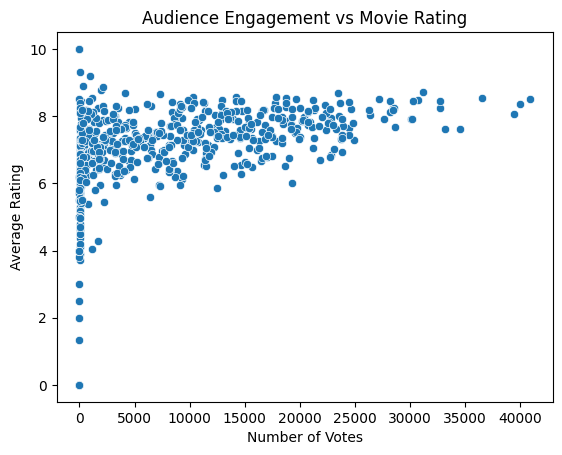

In [45]:
### Using Scatterplot because both the variables are numeric and we want to find the relationshsip between them
sns.scatterplot(data=df, x="vote_count", y="vote_average" )

plt.title("Audience Engagement vs Movie Rating")
plt.xlabel("Number of Votes")
plt.ylabel("Average Rating")
plt.show()

In [46]:
df["vote_count"].corr(df["vote_average"])

np.float64(0.4189704684691672)

#### CONCLUSION :- There is a moderate positive correlation (0.42) between vote count and average rating. This suggests that movies receiving more votes tend to have slightly higher ratings. However, the relationship is not strong enough to conclude that a larger audience directly causes higher ratings.

## Question 4 — Which Years Produced the Strongest Movies?

In [47]:
year_analysis = df.groupby("release_year").agg(movie_count=("title", "count"), avg_rating=("vote_average", "mean"),avg_popularity=("popularity", "mean"),
                                               avg_vote_count=("vote_count", "mean"))

In [48]:
year_analysis.head().reset_index()

,release_year,movie_count,avg_rating,avg_popularity,avg_vote_count
0,1938.0,1,7.129,23.3857,8084.0
1,1939.0,1,7.583,19.8703,6239.0
2,1957.0,1,8.570,30.4904,10280.0
3,1960.0,1,8.408,20.5281,11200.0
4,1966.0,1,8.466,25.4001,9881.0


### Highest-rated years

In [49]:
year_analysis.sort_values("avg_rating",ascending=False).head(10)

,movie_count,avg_rating,avg_popularity,avg_vote_count
release_year,,,,
1972.0,1,8.6860,59.22640,23426.00
1957.0,1,8.5700,30.49040,10280.00
1994.0,4,8.4810,47.62205,28052.25
1966.0,1,8.4660,25.40010,9881.00
1960.0,1,8.4080,20.52810,11200.00
1985.0,1,8.3290,34.62090,22255.00
1980.0,2,8.2965,23.29615,19003.50
1989.0,1,8.2960,25.76470,12880.00
1979.0,2,8.2165,24.51895,13018.00


In [50]:
year_analysis.sort_values("avg_popularity", ascending=False).head(10)

,movie_count,avg_rating,avg_popularity,avg_vote_count
release_year,,,,
2026.0,151,6.751848,73.412020,692.490066
1972.0,1,8.686000,59.226400,23426.000000
1994.0,4,8.481000,47.622050,28052.250000
2001.0,8,7.484500,47.448862,16965.250000
2011.0,11,6.975091,41.074127,13402.818182
1991.0,1,8.165000,39.102200,14714.000000
2012.0,7,7.323857,38.515257,21101.428571
2008.0,6,7.364500,36.269867,21081.166667
1974.0,2,6.236500,35.088700,7121.000000


In [51]:
strong_years = year_analysis[year_analysis["movie_count"] >= 5]

In [52]:
strong_years.sort_values("avg_rating",ascending=False).head(10)

,movie_count,avg_rating,avg_popularity,avg_vote_count
release_year,,,,
1997.0,6,7.978667,24.958650,14042.333333
1998.0,5,7.936000,22.505680,11630.600000
2009.0,6,7.789500,32.206450,21668.666667
2000.0,5,7.785600,25.338360,12166.000000
2002.0,10,7.704400,28.790350,13588.300000
2006.0,6,7.688500,26.441950,15397.000000
1999.0,8,7.688375,28.221400,16420.875000
2004.0,8,7.604000,27.049387,14186.875000
2003.0,7,7.579000,25.782171,16969.000000


In [53]:
strong_years.sort_values("avg_popularity",ascending=False).head(10)

,movie_count,avg_rating,avg_popularity,avg_vote_count
release_year,,,,
2026.0,151,6.751848,73.412020,692.490066
2001.0,8,7.484500,47.448862,16965.250000
2011.0,11,6.975091,41.074127,13402.818182
2012.0,7,7.323857,38.515257,21101.428571
2008.0,6,7.364500,36.269867,21081.166667
2025.0,51,6.601392,33.871414,2278.921569
2018.0,12,7.370333,33.014308,16283.666667
2017.0,19,7.158526,32.993668,13621.157895
2009.0,6,7.789500,32.206450,21668.666667


#### CONCLUSIONS :- Older years such as 1972 and 1989 have exceptionally high average ratings, while recent years dominate in movie production and average popularity. Therefore, movie quality and movie popularity/production have not necessarily followed the same trend over time.

## Question 5 — Has Movie Production Increased Over Time?

In [54]:
production_by_year = df.groupby("release_year").size()
production_by_year

release_year
1938.0      1
1939.0      1
1957.0      1
1960.0      1
1966.0      1
1968.0      2
1972.0      1
1973.0      1
1974.0      2
1975.0      1
1976.0      3
1977.0      1
1979.0      2
1980.0      2
1981.0      1
1982.0      4
1983.0      2
1984.0      3
1985.0      1
1986.0      4
1987.0      3
1988.0      4
1989.0      1
1990.0      2
1991.0      1
1992.0      1
1993.0      3
1994.0      4
1995.0      6
1996.0      1
1997.0      6
1998.0      5
1999.0      8
2000.0      5
2001.0      8
2002.0     10
2003.0      7
2004.0      8
2005.0      9
2006.0      6
2007.0      7
2008.0      6
2009.0      6
2010.0     12
2011.0     11
2012.0      7
2013.0     11
2014.0     21
2015.0     18
2016.0     17
2017.0     19
2018.0     12
2019.0     16
2020.0      4
2021.0     22
2022.0     17
2023.0     17
2024.0     26
2025.0     51
2026.0    151
dtype: int64

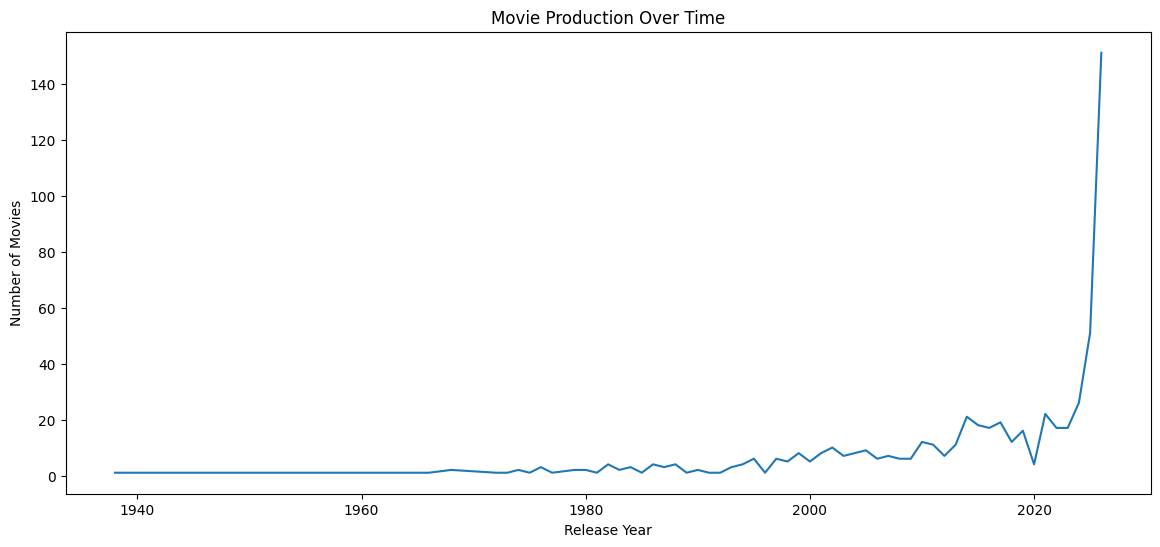

In [55]:
plt.figure(figsize=(14,6))

production_by_year.plot()

plt.title("Movie Production Over Time")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")

plt.show()

#### CONCLUSION :- We can see that the number of movies has increased over time. The older years have fewer movies, while recent years have many more movies. But since this is only a sample of **`popular movies`**, we cannot say that this represents the entire movie industry.

## Question 6 — Which Genres Dominate the Industry?

In [56]:
genre_counts = genre_df["genres"].value_counts()
genre_counts

genres
Action             215
Adventure          198
Drama              168
Thriller           160
Comedy             138
Science Fiction    135
Fantasy             96
Family              89
Animation           85
Horror              84
Crime               80
Romance             62
Mystery             43
War                 17
History             11
Western              8
Music                8
TV Movie             6
Documentary          2
Name: count, dtype: int64

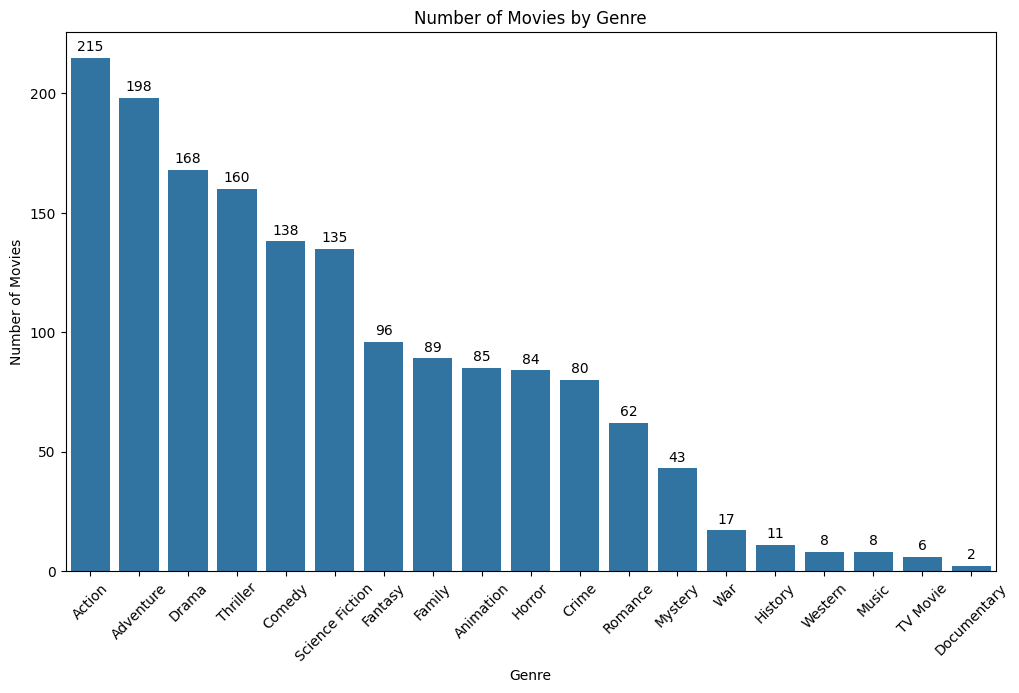

In [57]:
plt.figure(figsize=(12,7))

ax = sns.barplot(x=genre_counts.index, y = genre_counts.values)

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.title("Number of Movies by Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)

plt.show()

#### CONCLUSION :- Action is the most common genre in our dataset, followed by Adventure, Drama, and Thriller. Comedy and Science Fiction also have a significant number of movies. Hence This shows that Action, Adventure, Drama, and Thriller are the dominant genres in the dataset.

## Question 7 — Does Movie Popularity Depend on Ratings?

In [58]:
df.columns

Index(['adult', 'backdrop_path', 'genre_ids', 'id', 'title',
       'original_language', 'original_title', 'overview', 'popularity',
       'poster_path', 'release_date', 'softcore', 'video', 'vote_average',
       'vote_count', 'release_year', 'decade', 'genres'],
      dtype='object')

#### NOTE :- The two columns on which we have to work is 'popularity' and 'vote_average' . Both are Numerical cols and we have to find Relationship between them. so for this also we will have to find the correlation and scatterplot

In [59]:
df[['popularity','vote_average']].head()

,popularity,vote_average
0,1346.7581,7.893
1,620.9085,7.992
2,534.5399,6.541
3,317.4746,5.545
4,308.0179,8.227


In [60]:
correlation = df[["popularity", "vote_average"]].corr()

correlation

,popularity,vote_average
popularity,1.000000,0.034653
vote_average,0.034653,1.000000


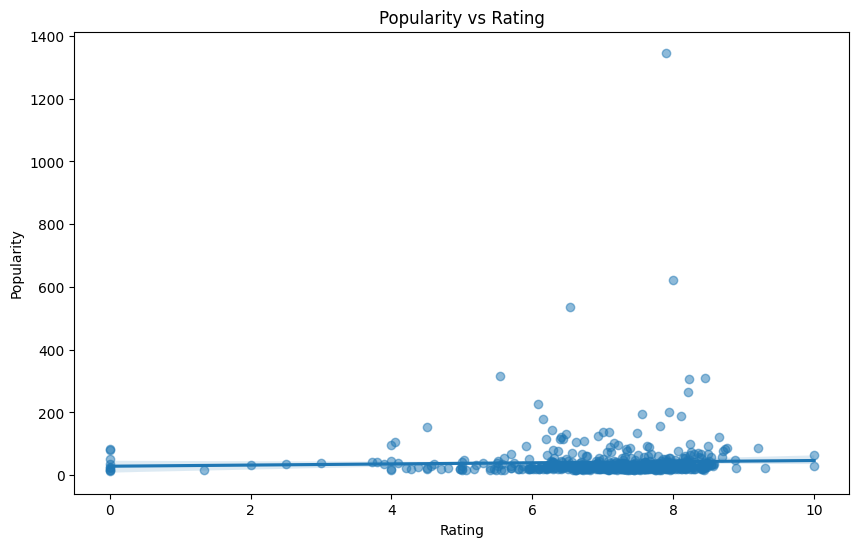

In [61]:
plt.figure(figsize=(10,6))

sns.regplot(data=df,x="vote_average",y="popularity", scatter_kws={"alpha": 0.5})

plt.title("Popularity vs Rating")
plt.xlabel("Rating")
plt.ylabel("Popularity")

plt.show()

#### CONCLUSIONS :- A high rating does not always mean a movie is popular. Some highly rated movies have low popularity, while some very popular movies have average ratings. This suggests that a movie's popularity depends on other factors, not just its rating.

## Question 8 — Are Highly Voted Movies More Reliable?

In [62]:
df["vote_count"].describe()

count      585.000000
mean      8402.405128
std       8641.381910
min          0.000000
25%        635.000000
50%       5851.000000
75%      14140.000000
max      40908.000000
Name: vote_count, dtype: float64

In [63]:
df.sort_values("vote_count", ascending=False)[["title", "vote_average", "vote_count"]].head(20)

,title,vote_average,vote_count
59,Interstellar,8.500,40908
69,Inception,8.372,39995
54,The Avengers,8.070,39422
84,The Dark Knight,8.534,36506
195,Avatar,7.609,34520
202,Deadpool,7.626,33181
137,Fight Club,8.437,32710
36,Avengers: Infinity War,8.241,32700
43,The Shawshank Redemption,8.728,31141
149,Pulp Fiction,8.481,30724
